# Exploratory Data Analysis — Raw Data Overview

This notebook performs an initial exploratory data analysis (EDA) on the raw CSV files contained in `src/data/raw`.

Goals
- Load and validate the raw CSV files.
- Inspect schema, sample rows, and basic summary statistics.
- Identify missing values, inconsistent types, and obvious data-quality issues.
- Produce simple visualizations that highlight key distributions and relationships.
- Prepare a small, documented set of cleaning steps to apply before feature engineering.

Raw files referenced
- `cleaned_merged_seasons.csv` — merged season-level data produced earlier.
- `fpl_playerstats_2024-25.csv` — player-level statistics for the 2024–25 season.
- `master_team_list.csv` — canonical list of teams and metadata.

Notes / Assumptions
- Files live in `src/data/raw` relative to this repository root.
- This is a lightweight, iterative EDA — heavy modeling or feature engineering will be done in separate scripts/notebooks.


### Setup — imports and environment

This cell imports the commonly used libraries for EDA, sets a couple of display options, and locates the raw data directory so subsequent cells can load files consistently.

In [ ]:
# Imports and basic setup
import os
from pathlib import Path
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 200)




### Load raw CSVs

Read the three raw CSV files into pandas DataFrames and display a small sample and the dtypes for each to validate schema assumptions.

In [ ]:


paths = {
    'merged_seasons': Path("../data/raw/cleaned_merged_seasons.csv"),
    'playerstats_2024_25': Path("../data/raw/fpl_playerstats_2024-25.csv"),
    'master_team_list': Path("../data/raw/master_team_list.csv")
}

dfs = {}
for name, path in paths.items():
    if not path.exists():
        print(f"⚠️ Warning: {path} does not exist")
        dfs[name] = None
        continue
    df = pd.read_csv(path)
    dfs[name] = df
    print(f"\n✅ {name} — {path.name}: {df.shape[0]} rows x {df.shape[1]} cols")
    display(df.head(3))
    display(df.dtypes)



✅ merged_seasons — cleaned_merged_seasons.csv: 96169 rows x 37 cols


C:\Users\omarf\AppData\Local\Temp\ipykernel_9940\1648213832.py:13: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW
0,2016-17,Aaron Cresswell,DEF,NaN,0,0,0,0,0.0,454,10,0,0,0.0,0.0,2016-08-15T19:00:00Z,0,4,Chelsea,0,0,0,0,1,0,14023,1.0,2.0,0.0,0,0,0,0,55,False,0,1
1,2016-17,Aaron Lennon,MID,NaN,0,0,6,0,0.3,142,3,0,0,0.9,8.2,2016-08-13T14:00:00Z,15,17,Spurs,0,0,0,0,1,0,13918,1.0,1.0,0.0,1,0,0,0,60,True,0,1
2,2016-17,Aaron Ramsey,MID,NaN,0,0,5,0,4.9,16,8,3,0,3.0,2.2,2016-08-14T15:00:00Z,60,9,Liverpool,0,0,0,0,1,0,163170,4.0,3.0,23.0,2,0,0,0,80,True,0,1


season_x              object
name                  object
position              object
team_x                object
assists                int64
bonus                  int64
bps                    int64
clean_sheets           int64
creativity           float64
element                int64
fixture                int64
goals_conceded         int64
goals_scored           int64
ict_index            float64
influence            float64
kickoff_time          object
minutes                int64
opponent_team          int64
opp_team_name         object
own_goals              int64
penalties_missed       int64
penalties_saved        int64
red_cards              int64
round                  int64
saves                  int64
selected               int64
team_a_score         float64
team_h_score         float64
threat               float64
total_points           int64
transfers_balance      int64
transfers_in           int64
transfers_out          int64
value                  int64
was_home      


✅ playerstats_2024_25 — fpl_playerstats_2024-25.csv: 661 rows x 32 cols


,id,player_cost,first_name,second_name,player_form,status,minutes,player_position,goals_scored,assists,clean_sheets,expected_goals,expected_assists,goals_conceded,expected_goals_conceded,influence,creativity,threat,bonus,penalties_saved,saves,yellow_cards,red_cards,gw1_points,gw2_points,gw3_points,gw4_points,gw5_points,team_name,team_form,team_strength,total_points
0,1,5.4,Fábio,Ferreira Vieira,0.0,Unavailable,0,MID,0,0,0,0.0,0.00,0,0.00,0.0,0.0,0.0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,Arsenal,NaN,5,0.0
1,2,6.8,Gabriel,Fernando de Jesus,0.3,Available,18,FWD,0,0,0,0.0,0.00,1,0.97,10.2,0.8,0.0,0,0,0,2,0,0.0,0.0,0.0,1.0,0.0,Arsenal,NaN,5,1.0
2,3,6.1,Gabriel,dos Santos Magalhães,8.0,Available,450,DEF,2,0,3,1.0,0.06,3,6.48,170.6,25.6,92.0,4,0,0,1,0,6.0,6.0,2.0,15.0,7.0,Arsenal,NaN,5,36.0


id                           int64
player_cost                float64
first_name                  object
second_name                 object
player_form                float64
status                      object
minutes                      int64
player_position             object
goals_scored                 int64
assists                      int64
clean_sheets                 int64
expected_goals             float64
expected_assists           float64
goals_conceded               int64
expected_goals_conceded    float64
influence                  float64
creativity                 float64
threat                     float64
bonus                        int64
penalties_saved              int64
saves                        int64
yellow_cards                 int64
red_cards                    int64
gw1_points                 float64
gw2_points                 float64
gw3_points                 float64
gw4_points                 float64
gw5_points                 float64
team_name           


✅ master_team_list — master_team_list.csv: 140 rows x 3 cols


,season,team,team_name
0,2016-17,1,Arsenal
1,2016-17,2,Bournemouth
2,2016-17,3,Burnley


season       object
team          int64
team_name    object
dtype: object

### Quick summary: shapes, memory and dtypes

This cell prints the shape, memory usage (approx), and dtypes for each loaded DataFrame in `dfs`. It helps confirm the files were loaded and gives a fast sanity check.

In [ ]:
# Quick summary for each DataFrame
for name, df in dfs.items():
    print('\n---', name, '---')
    if df is None:
        print('Not loaded')
        continue
    print('shape:', df.shape)
    try:
        mem = df.memory_usage(deep=True).sum() / 1024**2
        print(f'memory usage: {mem:.2f} MB')
    except Exception:
        pass
    display(df.dtypes)
    display(df.head(5))



--- merged_seasons ---
shape: (96169, 37)
memory usage: 54.36 MB


season_x              object
name                  object
position              object
team_x                object
assists                int64
bonus                  int64
bps                    int64
clean_sheets           int64
creativity           float64
element                int64
fixture                int64
goals_conceded         int64
goals_scored           int64
ict_index            float64
influence            float64
kickoff_time          object
minutes                int64
opponent_team          int64
opp_team_name         object
own_goals              int64
penalties_missed       int64
penalties_saved        int64
red_cards              int64
round                  int64
saves                  int64
selected               int64
team_a_score         float64
team_h_score         float64
threat               float64
total_points           int64
transfers_balance      int64
transfers_in           int64
transfers_out          int64
value                  int64
was_home      

,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,opp_team_name,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW
0,2016-17,Aaron Cresswell,DEF,NaN,0,0,0,0,0.0,454,10,0,0,0.0,0.0,2016-08-15T19:00:00Z,0,4,Chelsea,0,0,0,0,1,0,14023,1.0,2.0,0.0,0,0,0,0,55,False,0,1
1,2016-17,Aaron Lennon,MID,NaN,0,0,6,0,0.3,142,3,0,0,0.9,8.2,2016-08-13T14:00:00Z,15,17,Spurs,0,0,0,0,1,0,13918,1.0,1.0,0.0,1,0,0,0,60,True,0,1
2,2016-17,Aaron Ramsey,MID,NaN,0,0,5,0,4.9,16,8,3,0,3.0,2.2,2016-08-14T15:00:00Z,60,9,Liverpool,0,0,0,0,1,0,163170,4.0,3.0,23.0,2,0,0,0,80,True,0,1
3,2016-17,Abdoulaye Doucouré,MID,NaN,0,0,0,0,0.0,482,7,0,0,0.0,0.0,2016-08-13T14:00:00Z,0,13,Southampton,0,0,0,0,1,0,1051,1.0,1.0,0.0,0,0,0,0,50,False,0,1
4,2016-17,Adam Forshaw,MID,NaN,0,0,3,0,1.3,286,6,1,0,0.3,2.0,2016-08-13T14:00:00Z,69,14,Stoke,0,0,0,0,1,0,2723,1.0,1.0,0.0,1,0,0,0,45,True,1,1



--- playerstats_2024_25 ---
shape: (661, 32)
memory usage: 0.31 MB


id                           int64
player_cost                float64
first_name                  object
second_name                 object
player_form                float64
status                      object
minutes                      int64
player_position             object
goals_scored                 int64
assists                      int64
clean_sheets                 int64
expected_goals             float64
expected_assists           float64
goals_conceded               int64
expected_goals_conceded    float64
influence                  float64
creativity                 float64
threat                     float64
bonus                        int64
penalties_saved              int64
saves                        int64
yellow_cards                 int64
red_cards                    int64
gw1_points                 float64
gw2_points                 float64
gw3_points                 float64
gw4_points                 float64
gw5_points                 float64
team_name           

,id,player_cost,first_name,second_name,player_form,status,minutes,player_position,goals_scored,assists,clean_sheets,expected_goals,expected_assists,goals_conceded,expected_goals_conceded,influence,creativity,threat,bonus,penalties_saved,saves,yellow_cards,red_cards,gw1_points,gw2_points,gw3_points,gw4_points,gw5_points,team_name,team_form,team_strength,total_points
0,1,5.4,Fábio,Ferreira Vieira,0.0,Unavailable,0,MID,0,0,0,0.00,0.00,0,0.00,0.0,0.0,0.0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,Arsenal,NaN,5,0.0
1,2,6.8,Gabriel,Fernando de Jesus,0.3,Available,18,FWD,0,0,0,0.00,0.00,1,0.97,10.2,0.8,0.0,0,0,0,2,0,0.0,0.0,0.0,1.0,0.0,Arsenal,NaN,5,1.0
2,3,6.1,Gabriel,dos Santos Magalhães,8.0,Available,450,DEF,2,0,3,1.00,0.06,3,6.48,170.6,25.6,92.0,4,0,0,1,0,6.0,6.0,2.0,15.0,7.0,Arsenal,NaN,5,36.0
3,4,8.1,Kai,Havertz,4.0,Available,450,FWD,2,1,3,1.63,0.12,3,6.48,136.0,60.4,144.0,5,0,0,0,0,12.0,2.0,8.0,2.0,2.0,Arsenal,NaN,5,26.0
4,5,4.0,Karl,Hein,0.0,Unavailable,0,GKP,0,0,0,0.00,0.00,0,0.00,0.0,0.0,0.0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,Arsenal,NaN,5,0.0



--- master_team_list ---
shape: (140, 3)
memory usage: 0.02 MB


season       object
team          int64
team_name    object
dtype: object

,season,team,team_name
0,2016-17,1,Arsenal
1,2016-17,2,Bournemouth
2,2016-17,3,Burnley
3,2016-17,4,Chelsea
4,2016-17,5,Crystal Palace


In [ ]:
import pandas as pd

### Missing-value diagnostics

Show counts and percent-missing per column for each DataFrame, and list columns with any missing values so we can prioritise cleaning.

In [ ]:
# Missing value diagnostics
for name, df in dfs.items():
    print('\n---', name, '---')
    if df is None:
        print('Not loaded')
        continue
    miss = df.isna().sum()
    miss = miss[miss > 0].sort_values(ascending=False)
    if miss.empty:
        print('No missing values found.')
    else:
        pct = (miss / len(df) * 100).round(2)
        display(pd.concat([miss.rename('missing_count'), pct.rename('missing_percent')], axis=1))



--- merged_seasons ---


,missing_count,missing_percent
team_x,19852,20.64



--- playerstats_2024_25 ---


,missing_count,missing_percent
team_form,661,100.00
gw1_points,45,6.81
gw2_points,34,5.14
gw3_points,13,1.97
gw4_points,2,0.30



--- master_team_list ---
No missing values found.


### Numeric summary & correlations

Compute numeric summaries (describe) and show a correlation heatmap for the largest loaded numeric DataFrame(s). This helps find useful predictive relationships.


--- merged_seasons ---


,count,mean,std,min,25%,50%,75%,max
assists,96169.0,0.041042,0.215378,0.0,0.0,0.0,0.0,4.0
bonus,96169.0,0.108715,0.492334,0.0,0.0,0.0,0.0,3.0
bps,96169.0,6.080275,9.850595,-21.0,0.0,0.0,10.0,128.0
clean_sheets,96169.0,0.106739,0.308783,0.0,0.0,0.0,0.0,1.0
creativity,96169.0,4.734000,10.689879,0.0,0.0,0.0,2.4,170.9
element,96169.0,327.063264,194.313766,1.0,159.0,318.0,486.0,778.0
fixture,96169.0,198.413824,108.884200,1.0,105.0,203.0,293.0,380.0
goals_conceded,96169.0,0.495887,0.974269,0.0,0.0,0.0,1.0,9.0
goals_scored,96169.0,0.045514,0.233644,0.0,0.0,0.0,0.0,4.0
ict_index,96169.0,1.715793,3.042551,0.0,0.0,0.0,2.5,32.8


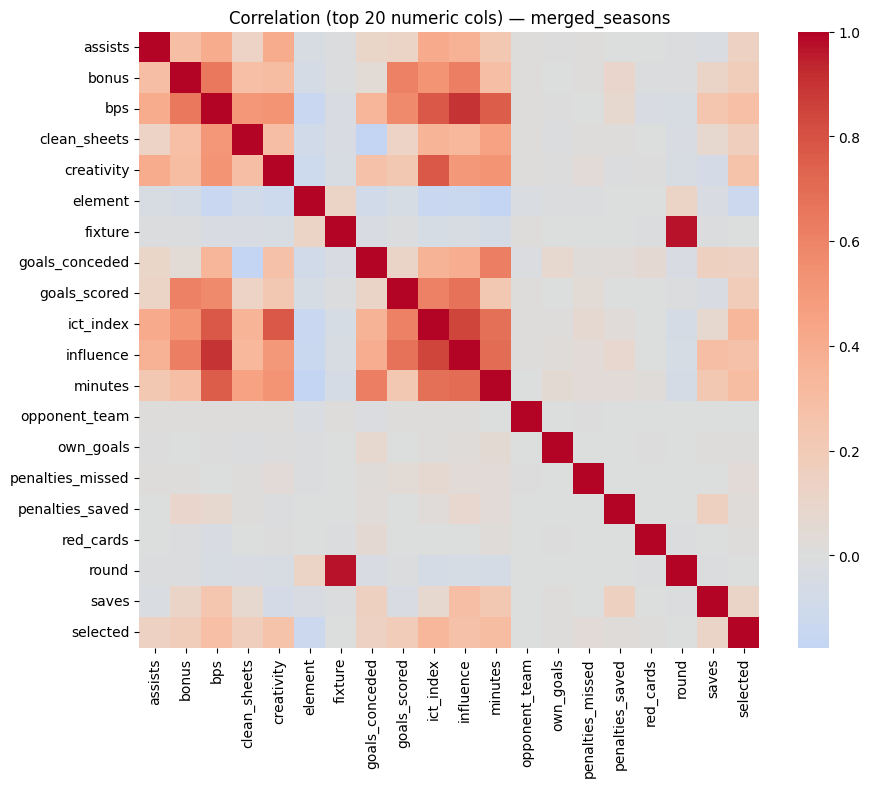


--- playerstats_2024_25 ---


,count,mean,std,min,25%,50%,75%,max
id,661.0,331.000000,190.958547,1.0,166.0,331.00,496.00,661.00
player_cost,661.0,4.999092,1.053062,4.0,4.5,4.80,5.30,15.30
player_form,661.0,1.194554,1.783791,-0.3,0.0,0.30,1.70,13.00
minutes,661.0,148.954614,169.273218,0.0,0.0,65.00,299.00,450.00
goals_scored,661.0,0.201210,0.698742,0.0,0.0,0.00,0.00,10.00
assists,661.0,0.183056,0.543349,0.0,0.0,0.00,0.00,5.00
clean_sheets,661.0,0.397882,0.818681,0.0,0.0,0.00,1.00,5.00
expected_goals,661.0,0.216989,0.507937,0.0,0.0,0.00,0.19,5.69
expected_assists,661.0,0.153933,0.321295,0.0,0.0,0.01,0.14,2.86
goals_conceded,661.0,2.263238,3.003078,0.0,0.0,1.00,4.00,14.00


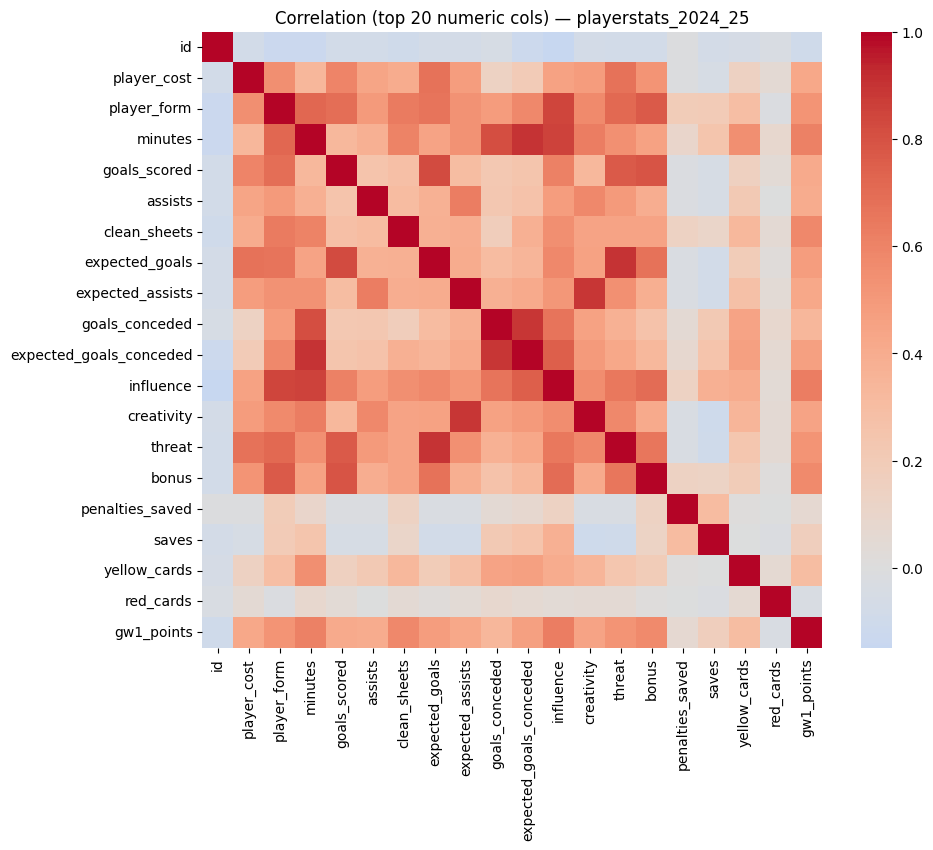


--- master_team_list ---


,count,mean,std,min,25%,50%,75%,max
team,140.0,10.5,5.786986,1.0,5.75,10.5,15.25,20.0


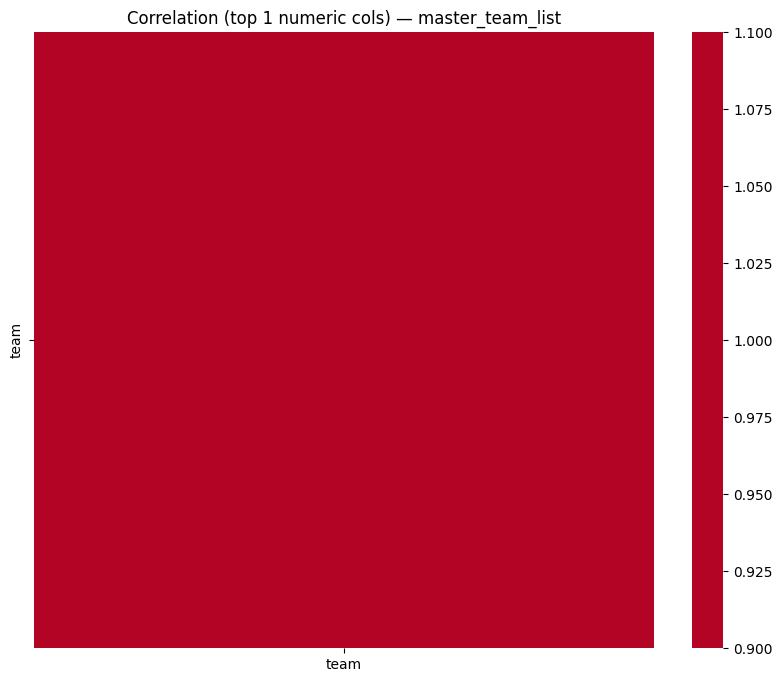

In [ ]:
# Numeric summary and correlations
import matplotlib.pyplot as plt
import seaborn as sns

for name, df in dfs.items():
    print('\n---', name, '---')
    if df is None:
        print('Not loaded')
        continue
    num = df.select_dtypes(include=['number'])
    if num.shape[1] == 0:
        print('No numeric columns to summarise')
        continue
    display(num.describe().T)
    # correlation heatmap (limit to 20 cols for readability)
    cols = num.columns.tolist()[:20]
    corr = num[cols].corr()
    plt.figure(figsize=(10, 8))
    mask = None
    sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, mask=mask)
    plt.title(f'Correlation (top {len(cols)} numeric cols) — {name}')
    plt.show()


### Initial visualizations

Plot distributions for a few key numeric columns (if present) and show top categories for likely categorical columns (team names, positions). The code is defensive — it checks column existence before plotting.


=== merged_seasons ===


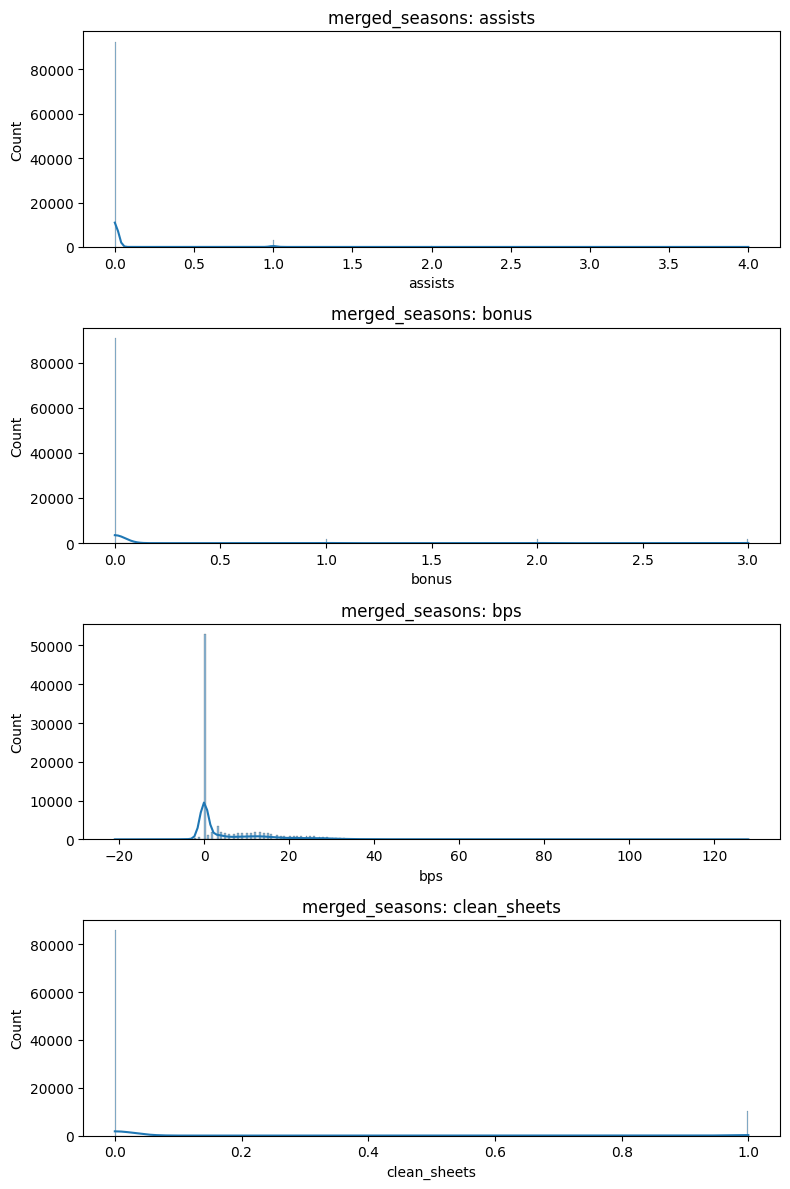


Top categories for position


position
MID    39163
DEF    33683
FWD    12669
GK     10553
GKP      101
Name: count, dtype: int64


=== playerstats_2024_25 ===


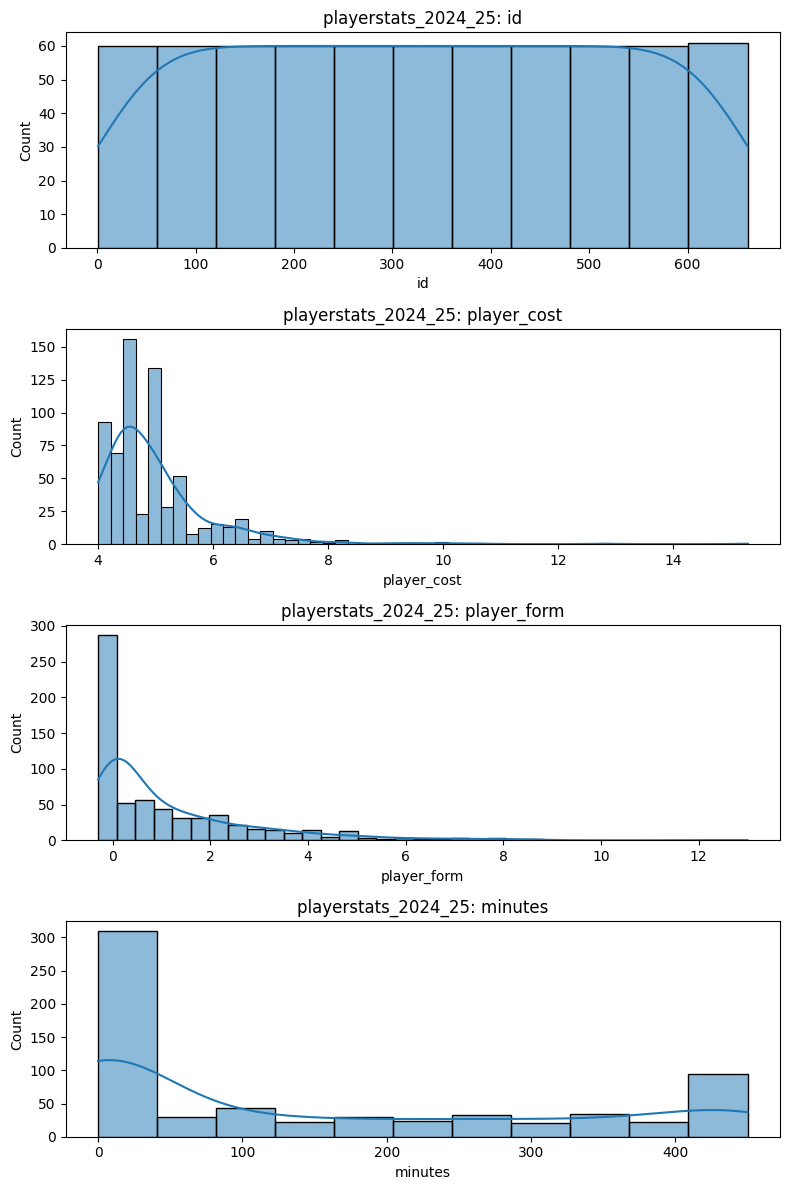


Top categories for team_name


team_name
Brighton         43
Chelsea          40
Wolves           38
Aston Villa      37
Southampton      37
Spurs            36
Brentford        33
Nott'm Forest    33
Newcastle        33
Ipswich          33
Name: count, dtype: int64


=== master_team_list ===


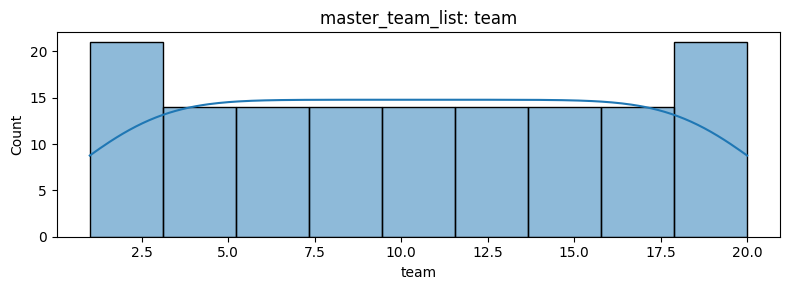


Top categories for team


team
1     7
2     7
3     7
4     7
5     7
6     7
7     7
8     7
9     7
10    7
Name: count, dtype: int64


Top categories for team_name


team_name
Arsenal           7
Chelsea           7
Everton           7
Crystal Palace    7
Leicester         7
Man Utd           7
Man City          7
Liverpool         7
Southampton       7
Spurs             7
Name: count, dtype: int64

In [ ]:
# Initial visualizations
import matplotlib.pyplot as plt
import seaborn as sns

for name, df in dfs.items():
    print('\n===', name, '===')
    if df is None:
        print('Not loaded')
        continue
    num = df.select_dtypes(include=['number'])
    # pick up to 4 numeric cols to plot distributions
    plot_cols = num.columns.tolist()[:4]
    if plot_cols:
        fig, axes = plt.subplots(len(plot_cols), 1, figsize=(8, 3 * len(plot_cols)))
        if len(plot_cols) == 1:
            axes = [axes]
        for ax, col in zip(axes, plot_cols):
            sns.histplot(df[col].dropna(), kde=True, ax=ax)
            ax.set_title(f"{name}: {col}")
        plt.tight_layout()
        plt.show()
    else:
        print('No numeric columns to plot.')

    # show top categorical columns candidates
    candidates = [c for c in df.columns if c.lower() in ('team','team_name','club','position','element_type','player')]
    for c in candidates:
        print('\nTop categories for', c)
        display(df[c].value_counts().head(10))


### Duplicate rows check

This cell checks each loaded DataFrame for fully duplicated rows and common-identifier duplicates (e.g., `player_id`, `player_name + round`). It prints counts, percentages, and shows a small sample of duplicate rows to help decide cleaning steps.

In [ ]:
# Duplicate diagnostics
from IPython.display import display

for name, df in dfs.items():
    print('\n--- Duplicate check:', name, '---')
    if df is None:
        print('Not loaded')
        continue
    n = len(df)
    if n == 0:
        print('Empty dataframe')
        continue
    total_dup = int(df.duplicated().sum())
    print(f'Total fully duplicated rows: {total_dup} ({total_dup / n * 100:.3f}% )')
    if total_dup > 0:
        display(df[df.duplicated()].head(10))

    # Check duplicates on typical identifier columns if present
    id_candidates = [c for c in ('id', 'player_id', 'element', 'element_id', 'team_id', 'code') if c in df.columns]
    for c in id_candidates:
        dupc = int(df.duplicated(subset=[c]).sum())
        print(f'Duplicated by `{c}`: {dupc} ({dupc / n * 100:.3f}% )')

    # Check composite keys commonly used in player-level stats
    composite_keys = []
    if 'player_id' in df.columns and 'round' in df.columns:
        composite_keys.append(['player_id', 'round'])
    if 'player_name' in df.columns and 'round' in df.columns:
        composite_keys.append(['player_name', 'round'])
    if 'team' in df.columns and 'fixture' in df.columns:
        composite_keys.append(['team', 'fixture'])

    for keys in composite_keys:
        dupk = int(df.duplicated(subset=keys).sum())
        print(f'Duplicated by {keys}: {dupk} ({dupk / n * 100:.3f}% )')

    # Quick note if duplicates exist
    if total_dup == 0 and all(int(df.duplicated(subset=[c]).sum()) == 0 for c in id_candidates) and all(int(df.duplicated(subset=k).sum()) == 0 for k in composite_keys):
        print('No obvious duplicates found.')
    else:
        print('Consider how to deduplicate (keep first/last, aggregate, or check source).')



--- Duplicate check: merged_seasons ---
Total fully duplicated rows: 0 (0.000% )
Duplicated by `element`: 95391 (99.191% )
Consider how to deduplicate (keep first/last, aggregate, or check source).

--- Duplicate check: playerstats_2024_25 ---
Total fully duplicated rows: 0 (0.000% )
Duplicated by `id`: 0 (0.000% )
No obvious duplicates found.

--- Duplicate check: master_team_list ---
Total fully duplicated rows: 0 (0.000% )
No obvious duplicates found.
Total fully duplicated rows: 0 (0.000% )
Duplicated by `element`: 95391 (99.191% )
Consider how to deduplicate (keep first/last, aggregate, or check source).

--- Duplicate check: playerstats_2024_25 ---
Total fully duplicated rows: 0 (0.000% )
Duplicated by `id`: 0 (0.000% )
No obvious duplicates found.

--- Duplicate check: master_team_list ---
Total fully duplicated rows: 0 (0.000% )
No obvious duplicates found.
